<a href="https://colab.research.google.com/github/ketanp23/deeplearningclass/blob/main/DL_Lab3_Gradient_Descent_and_Loss_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DL Lab 3 · Gradient-Based Learning & Loss Functions

> **Deep Learning foundations — Lab.** Run top to bottom (Runtime → Run all). Read the notes, run the code, and finish
> the **Your turn 🧪** cell. We build from scratch with NumPy so nothing is hidden.

## What you'll build
The engine of all training — **gradient descent** — and the **loss functions** it minimizes (MSE for regression,
cross-entropy for classification). You'll feel how the **learning rate** makes or breaks learning.

In [1]:
import numpy as np, matplotlib.pyplot as plt
VIOLET, CYAN, ROSE = "#6C5CE7", "#22D3EE", "#FB7185"

## 1 · Gradient descent on a simple bowl
Minimize $f(w)=w^2$. The gradient is $f'(w)=2w$; step against it: $w \leftarrow w - \eta\, f'(w)$.

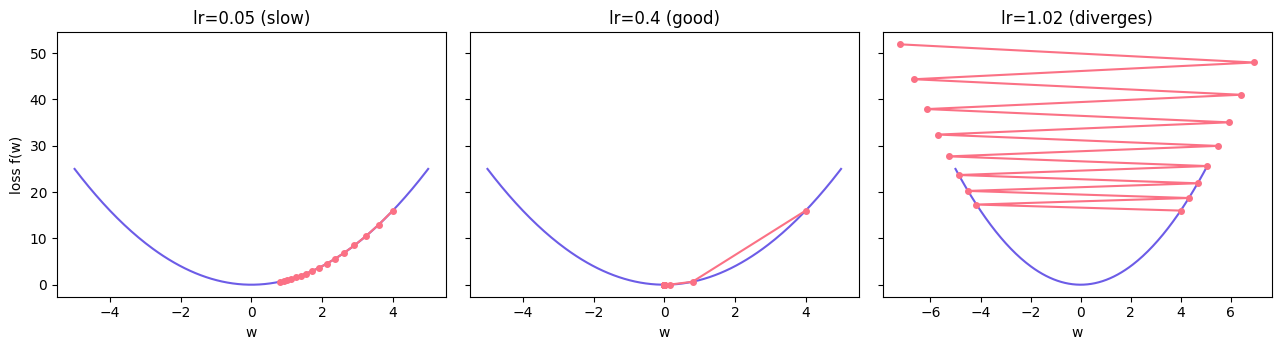

Too small: crawls. Just right: converges. Too big: overshoots and explodes.


In [2]:
f  = lambda w: w**2
df = lambda w: 2*w

def descend(lr, steps=15, w0=4.0):
    w, path = w0, [w0]
    for _ in range(steps):
        w = w - lr*df(w); path.append(w)
    return np.array(path)

grid = np.linspace(-5,5,200)
fig, ax = plt.subplots(1,3, figsize=(13,3.6), sharey=True)
for a,(lr,title) in zip(ax, [(0.05,"lr=0.05 (slow)"),(0.4,"lr=0.4 (good)"),(1.02,"lr=1.02 (diverges)")]):
    a.plot(grid, f(grid), color=VIOLET)
    p = descend(lr)
    a.plot(p, f(p), 'o-', color=ROSE, ms=4)
    a.set_title(title); a.set_xlabel("w")
ax[0].set_ylabel("loss f(w)"); plt.tight_layout(); plt.show()
print("Too small: crawls. Just right: converges. Too big: overshoots and explodes.")

## 2 · Loss functions — MSE vs cross-entropy
For a true label and a predicted probability, how much penalty?

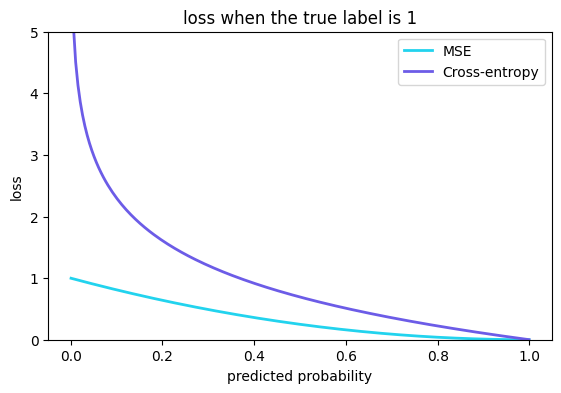

Cross-entropy shoots to infinity for a confident wrong answer -> a much stronger correction signal.


In [3]:
p = np.linspace(0.001, 0.999, 200)
mse_pos = (p - 1)**2                       # true label = 1
ce_pos  = -np.log(p)                        # cross-entropy, true label = 1
plt.figure(figsize=(6.5,4))
plt.plot(p, mse_pos, color=CYAN, lw=2, label="MSE")
plt.plot(p, ce_pos,  color=VIOLET, lw=2, label="Cross-entropy")
plt.title("loss when the true label is 1"); plt.xlabel("predicted probability"); plt.ylabel("loss")
plt.legend(); plt.ylim(0,5); plt.show()
print("Cross-entropy shoots to infinity for a confident wrong answer -> a much stronger correction signal.")

## 3 · Fit a line by gradient descent
Put it together: learn `w, b` for `y = w*x + b` from noisy data using MSE and its gradients.

learned  w=1.922  b=0.564   (true 2.0, 0.5)


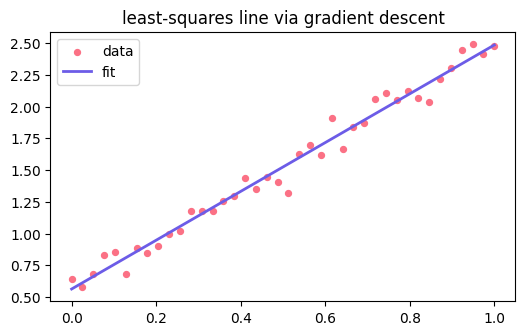

In [4]:
np.random.seed(0)
x = np.linspace(0,1,40); y = 2.0*x + 0.5 + np.random.randn(40)*0.08
w, b, lr, hist = 0.0, 0.0, 0.5, []
for _ in range(400):
    yh = w*x + b
    err = yh - y
    w -= lr * (2*err*x).mean()
    b -= lr * (2*err).mean()
    hist.append((err**2).mean())
print(f"learned  w={w:.3f}  b={b:.3f}   (true 2.0, 0.5)")
plt.figure(figsize=(6,3.5)); plt.scatter(x,y,s=18,color=ROSE,label="data")
plt.plot(x, w*x+b, color=VIOLET, lw=2, label="fit"); plt.legend(); plt.title("least-squares line via gradient descent"); plt.show()

## Your turn 🧪
1. In section 1, find the learning rate where descent *just* starts to diverge. (For `w²` it's exactly 1.0 — why?)
2. Add **momentum**: keep a running velocity `v = 0.9*v - lr*grad; w += v`. Does it reach the bottom faster?
3. Plot cross-entropy for a true label of **0** instead of 1 — where does it blow up now?

In [5]:
# Your turn: momentum
v, w = 0.0, 4.0; path=[w]
for _ in range(15):
    v = 0.9*v - 0.2*(2*w); w += v; path.append(w)
print("with momentum, w after 15 steps:", round(w,4))

with momentum, w after 15 steps: -1.417
